# Bandit パラメータ sweep: Q 学習の学習曲線

2 本腕バンディット上の Q 学習について、学習率 α と逆温度 β を振り、
学習曲線（最適腕を選んだ割合）と累積後悔（cumulative regret）がどう変わるかを比較する。

| セクション | 内容 |
|---|---|
| 1 | セットアップ |
| 2 | 実行パラメータ設定 |
| 3 | run.jl 実行 |
| 4 | 結果読み込み・集計 |
| 5 | 学習曲線の比較 |
| 6 | 最終性能サマリ |
| 7 | 累積 regret の比較 |

## 1. セットアップ

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io=devnull)  # このノートブックが属するプロジェクト環境を有効化
Pkg.instantiate(; io=devnull)                        # 必要なパッケージがなければ自動インストール

# 使用するパッケージを読み込む
# DrWatson : ファイルパス管理（datadir / projectdir など）
# CSV      : CSV ファイルの読み書き
# DataFrames: 表形式データの操作（R の data.frame に相当）
# Plots    : グラフ描画
# Statistics: mean など統計関数
# Printf   : @printf で書式付き出力
using DrWatson, CSV, DataFrames, Plots, Statistics, Printf

# src/bandit.jl を読み込む
# softmax_choice（腕の選択）と run_bandit（シミュレーション本体）が定義されている
include(srcdir("bandit.jl"))

run_bandit

## 2. 実行パラメータ設定

学習率 α と逆温度 β の組み合わせを sweep する。

In [2]:
# sweep（スウィープ）とは？
# ─────────────────────────────────────────────
# α と β の値を複数用意して、すべての組み合わせを試すことを「パラメータ sweep」という。
# 例: α ∈ {0.1, 0.3, 0.6} × β ∈ {2.0, 5.0} → 3×2 = 6 条件

# DrWatson の dict_list を使う
# ─────────────────────────────────────────────
# 「値がベクトルのキー → その要素すべてを総当たり（直積）」
# 「値がスカラーのキー → 全条件で固定」というルールで、
# 1 つの Dict から全組み合わせの Dict のリストを自動生成してくれる。
# パラメータを増やしたくなったら、ここに 1 行足すだけでよい。
allparams = Dict(
    :seed         => 42,              # 乱数シード（同じ値にすると結果を再現できる）
    :n_trials     => 100,             # 1 回のシミュレーションで何回腕を引くか
    :n_reps       => 200,             # シミュレーションを何回繰り返して平均を取るか
    :reward_probs => [[0.2, 0.8]],    # 各腕の報酬確率（腕1: 20%、腕2: 80%）
    :alpha        => [0.1, 0.3, 0.6], # Q 学習の学習率（3 通りを sweep）
    :beta         => [2.0, 5.0],      # softmax の逆温度（2 通りを sweep）
)
# 注意: reward_probs のように「値そのものがベクトル」のパラメータは、
# そのまま [0.2, 0.8] と書くと「0.2 と 0.8 の 2 条件を sweep する」と
# 解釈されてしまうため、[[0.2, 0.8]] と二重に囲んで固定値扱いにする。
# 将来 [[0.2, 0.8], [0.4, 0.6]] と並べれば、腕の確率設定も sweep に加わる。

paramsets = dict_list(allparams)  # 3×2 = 6 個の Dict が生成される

println("Total: $(length(paramsets))")  # 条件数を確認（dict_list_count(allparams) でも同じ）
paramsets

Total: 6


6-element Vector{Dict{Symbol, Any}}:
 Dict(:n_reps => 200, :alpha => 0.1, :beta => 2.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)
 Dict(:n_reps => 200, :alpha => 0.3, :beta => 2.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)
 Dict(:n_reps => 200, :alpha => 0.6, :beta => 2.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)
 Dict(:n_reps => 200, :alpha => 0.1, :beta => 5.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)
 Dict(:n_reps => 200, :alpha => 0.3, :beta => 5.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)
 Dict(:n_reps => 200, :alpha => 0.6, :beta => 5.0, :reward_probs => [0.2, 0.8], :seed => 42, :n_trials => 100)

## 3. run.jl 実行

各パラメータ条件について `scripts/run.jl` をサブプロセスで実行し、
結果を `datadir("sims")` に CSV 保存する。

In [ ]:
# なぜサブプロセスで実行するのか？
# ─────────────────────────────────────────────
# scripts/run.jl を別プロセスとして呼び出すことで
#   ・ノートブックとシミュレーションのコードを分離できる
#   ・結果が CSV に保存されるため、ノートブックを再起動しても読み直せる

# produce-or-load 方式（DrWatson の produce_or_load と同じ考え方）
# ─────────────────────────────────────────────
# 出力 CSV がすでに存在する条件は再計算せずスキップする。
# ファイル名は src/io.jl の save_sim と同じ savename で決まるので、
# ここでも同じ規則でパスを組み立てて isfile で存在を確認する。
# 強制的に再計算したいときは force = true にする。
force = false

run_script = projectdir("scripts", "run.jl")  # run.jl の絶対パスを取得
julia_cmd  = Base.julia_cmd()                  # 実行中の julia と同じ実行コマンド（sysimage・フラグも引き継ぐ）
out_dir    = datadir("sims")                   # 出力先（save_sim と同じ）

for p in paramsets
    # save_sim と同じ規則で出力先パスを再現する
    # equals="-" は save_sim と合わせる（"=" 入りのパスは VS Code で
    # リンク化されないことがあるため "-" を使っている）
    fname_params = Dict(
        "alpha"    => p[:alpha],
        "beta"     => p[:beta],
        "n_arms"   => length(p[:reward_probs]),
        "seed"     => p[:seed],
        "n_trials" => p[:n_trials],
        "n_reps"   => p[:n_reps],
    )
    fpath = joinpath(out_dir, savename("bandit", fname_params, "csv"; equals="-"))

    # 既存ファイルがあり force=false なら計算をスキップ（produce_or_load の load 相当）
    if !force && isfile(fpath)
        println("Skip (exists): ", fpath)
        continue
    end

    # [Int, Int, Int, Float, Float] の配列リテラルは全要素を Float64 に昇格させるため、
    # string.([42, 100, 200, 0.1, 2.0]) → ["42.0", "100.0", ...] になる。
    # 各要素を先に個別 string() で文字列化することで型昇格を防ぐ。
    args = [string(p[:seed]), string(p[:n_trials]), string(p[:n_reps]),
            string(p[:alpha]), string(p[:beta]), string.(p[:reward_probs])...]
    cmd  = `$julia_cmd $run_script $args`  # バッククォートでシェルコマンドを組み立てる
    println("Running: julia scripts/run.jl $(join(args, " "))")
    run(cmd)  # サブプロセスとして実行。結果は data/sims/ に CSV 保存される
end

## 4. 結果読み込み・集計

保存した CSV を `savename` で特定して読み込み、1 つの DataFrame にまとめる。

In [4]:
sim_dir = datadir("sims")  # data/sims/ ディレクトリのパスを取得

# 各パラメータ条件の CSV を読み込んで 1 つの DataFrame にまとめる
rows = DataFrame[]  # 空の配列（DataFrame を格納するコンテナ）
for p in paramsets
    # savename はパラメータの Dict からファイル名を自動生成する DrWatson の機能
    # equals="-" は save_sim と合わせる（保存と読み込みで一致していないと読めない）
    # 例: "bandit_alpha-0.3_beta-5.0_n_arms-2_n_reps-200_n_trials-100_seed-42.csv"
    params = Dict(
        "alpha"    => p[:alpha],
        "beta"     => p[:beta],
        "n_arms"   => length(p[:reward_probs]),
        "seed"     => p[:seed],
        "n_trials" => p[:n_trials],
        "n_reps"   => p[:n_reps],
    )
    f = joinpath(sim_dir, savename("bandit", params, "csv"; equals="-"))
    isfile(f) || (println("Missing: ", f); continue)  # ファイルがなければスキップ
    push!(rows, CSV.read(f, DataFrame))                # DataFrame として読み込んでリストに追加
end

isempty(rows) && error("No result files were loaded.")

# vcat で複数の DataFrame を縦に連結（行を積み重ねる）
df = vcat(rows...)
println("Rows: $(nrow(df))")  # 全行数を確認（条件数 × n_trials = 6 × 100 = 600 行のはず）
first(df, 5)                  # 先頭 5 行を表示して中身を確認

Rows: 600


Row,trial,p_optimal,regret,alpha,beta,seed,n_trials,n_reps,p_arm1,p_arm2
,Int64,Float64,Float64,Float64,Float64,Int64,Int64,Int64,Float64,Float64
1,1,0.485,0.309,0.1,2.0,42,100,200,0.2,0.8
2,2,0.495,0.303,0.1,2.0,42,100,200,0.2,0.8
3,3,0.53,0.282,0.1,2.0,42,100,200,0.2,0.8
4,4,0.535,0.279,0.1,2.0,42,100,200,0.2,0.8
5,5,0.57,0.258,0.1,2.0,42,100,200,0.2,0.8


### 可視化用のデータフレームを作る。`accuracy` は最適腕を選んだ割合、`regret` は平均後悔。

In [ ]:
# α × β の条件ごとに最終性能と平均性能を集計する
# groupby  : 指定した列の値が同じ行をグループにまとめる
# combine  : 各グループに対して集計関数を適用する

# last で「最終試行」を取るため、集計前に trial 順へ並べておく
# （CSV は元々 trial 順だが、連結順に依存しないよう明示的にソートする）
sort!(df, [:alpha, :beta, :trial])

agg = combine(
    groupby(df, [:alpha, :beta]),
    :p_optimal => last => :final_p_optimal,  # 最終試行（trial=100）の P(optimal)
    :p_optimal => mean => :mean_p_optimal,   # 全試行の平均 P(optimal)
)
sort!(agg, [:alpha, :beta])  # α → β の順で並び替えて見やすくする
agg

## 5. 学習曲線の比較

パラメータ条件ごとに、最適腕を選んだ割合の推移を重ねて描画する。

In [ ]:
# α, β の各組み合わせについて学習曲線（P(optimal) の推移）を 1 枚のグラフに重ね描きする
# ─────────────────────────────────────────────
# plt に条件ごとの折れ線を順に追加していき、最後に PNG として保存する
plt = plot(;
    xlabel = "Trial",
    ylabel = "P(optimal)",
    title  = "Q-learning learning curves",
    ylim   = (0.5, 1),      # ランダム選択（0.5）より下は見せない
    legend = :bottomright,
    lw     = 2,
)

for p in paramsets
    # この条件（α, β）に対応する行だけを df から取り出す
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue  # 対応する結果がなければこの条件はスキップ
    sort!(sub, :trial)        # trial 順に並べ替えてから描画する（順不同だと折れ線が乱れる）
    plot!(plt, sub.trial, sub.p_optimal; label = "α=$(p[:alpha]), β=$(p[:beta])")
end

path = savefig(plt, plotsdir("learning_curves_sweep.png"))  # PNG として保存
println("Saved: ", path)  # 保存先パスを出力（クリックで開ける）
plt

## 6. 最終性能サマリ

In [7]:
# 各条件の最終性能（最後の試行の P(optimal)）と全試行平均を表示する
println("=== 最終性能（最後の試行の P(optimal)）===\n")
for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    # @printf : C 言語風の書式付き出力（%.3f → 小数点以下 3 桁）
    # α, β は Unicode のギリシャ文字（α, β）で表示している
    @printf("  α=%.1f  β=%.1f  final=%.3f  mean=%.3f\n",
        p[:alpha], p[:beta], sub.p_optimal[end], mean(sub.p_optimal))
end

=== 最終性能（最後の試行の P(optimal)）===

  α=0.1  β=2.0  final=0.750  mean=0.734
  α=0.3  β=2.0  final=0.735  mean=0.750
  α=0.6  β=2.0  final=0.715  mean=0.747
  α=0.1  β=5.0  final=0.960  mean=0.918
  α=0.3  β=5.0  final=0.930  mean=0.927
  α=0.6  β=5.0  final=0.875  mean=0.898


## 7. 累積 regret の比較

**cumulative regret（累積後悔）** = 各試行の `p_best - p_choice` の累積和。

- 傾きが急 → 最適腕を選べていない（探索が足りない or 学習が遅い）
- 傾きが緩やか → 早い段階で最適腕を特定できている

理想的なエージェントは「早めに最適腕を見つけてからは regret をほぼ増やさない」ため、
カーブが途中で頭打ちに近くなる。

Saved: /Users/oyokuratomo/Documents/bandit/BanditTutorial/plots/cumulative_regret_sweep.png


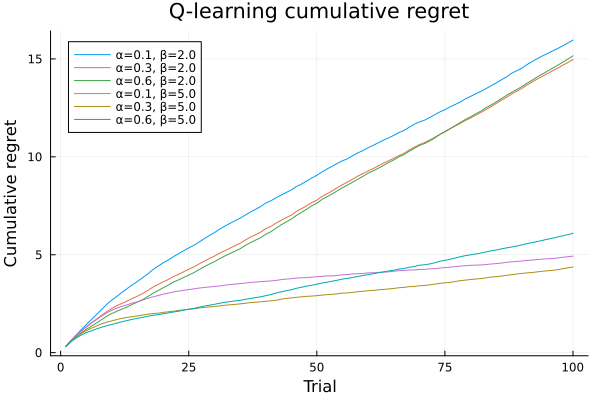

In [8]:
# 累積 regret を条件ごとにプロットする
# cumsum(sub.regret) : 各試行の regret を足し合わせた累積値
# 傾きが急 → 最適腕を選べていない（= 損失が大きい）
# 傾きが緩やか → 早い段階で最適腕を見つけられている（= 損失が少ない）

# 各条件で trial 順に並べた regret を累積し、学習が進むほど損失の増え方が小さくなるかを比較する
plt_reg = plot(;
    xlabel = "Trial",
    ylabel = "Cumulative regret",
    title  = "Q-learning cumulative regret",
    legend = :topleft,
    lw     = 2,
)

for p in paramsets
    sub = filter(r -> r.alpha == p[:alpha] && r.beta == p[:beta], df)
    isempty(sub) && continue
    sort!(sub, :trial)
    plot!(plt_reg, sub.trial, cumsum(sub.regret);
        label = "α=$(p[:alpha]), β=$(p[:beta])")
end

path = savefig(plt_reg, plotsdir("cumulative_regret_sweep.png"))  # PNG として保存
println("Saved: ", path)  # 保存先パスを出力（クリックで開ける）
plt_reg